# Proyek Machine Learning: Klasifikasi Kualitas Air (Water Potability)

**Mata Kuliah:** Machine Learning  
**Topik:** Klasifikasi  
**Dataset:** Water Potability Dataset (Kaggle)  
**Tujuan:** Memprediksi apakah air layak minum (Potable) atau tidak berdasarkan parameter kualitas air.  
**Kelompok:** 3  
**Anggota Kelompok:** 
- Muhammad Axel Savero Fikri (1313623004)
- Muhammad Adani Faza (1313623027)
- Andhika Dwiputra Soetjadi (1313623053)

## 1. Data dan Eksplorasi Data (EDA)

Pada tahap ini, kita akan memuat dataset, memahami struktur data, menampilkan statistik deskriptif, serta melakukan visualisasi untuk menemukan pola dan anomali dalam data.

### 1.1 Import Library

Langkah pertama adalah mengimpor semua library yang dibutuhkan. Kita menggunakan:
- **Pandas & NumPy** untuk manipulasi data
- **Matplotlib & Seaborn** untuk visualisasi
- **Scikit-Learn** untuk preprocessing, pemodelan, dan evaluasi

In [1]:
# ============================================================
# Import Library
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-Learn: Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-Learn: Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Scikit-Learn: Evaluasi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Konfigurasi tampilan
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✅ Semua library berhasil diimpor.')

✅ Semua library berhasil diimpor.


### 1.2 Memuat Dataset

Dataset `water_potability.csv` berisi 10 kolom parameter kualitas air. Kolom target adalah `Potability` yang bernilai:
- **1** = Air layak minum (Potable)
- **0** = Air tidak layak minum (Not Potable)

In [2]:
# ============================================================
# Memuat Dataset
# ============================================================
df = pd.read_csv('water_potability.csv')

# Menampilkan 5 baris pertama
print('=' * 60)
print('PREVIEW DATA (5 BARIS PERTAMA)')
print('=' * 60)
df.head()

PREVIEW DATA (5 BARIS PERTAMA)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.8905,20791.3190,7.3002,368.5164,564.3087,10.3798,86.9910,2.9631,0
1,3.7161,129.4229,18630.0579,6.6352,NaN,592.8854,15.1800,56.3291,4.5007,0
2,8.0991,224.2363,19909.5417,9.2759,NaN,418.6062,16.8686,66.4201,3.0559,0
3,8.3168,214.3734,22018.4174,8.0593,356.8861,363.2665,18.4365,100.3417,4.6288,0
4,9.0922,181.1015,17978.9863,6.5466,310.1357,398.4108,11.5583,31.9980,4.0751,0


In [3]:
# Dimensi dataset
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Jumlah fitur   : {df.shape[1] - 1}')
print(f'Kolom target   : Potability')
print(f'\nDaftar kolom   : {list(df.columns)}')

Jumlah baris   : 3276
Jumlah kolom   : 10
Jumlah fitur   : 9
Kolom target   : Potability

Daftar kolom   : ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


In [4]:
# Informasi tipe data dan non-null count
print('=' * 60)
print('INFORMASI DATASET')
print('=' * 60)
df.info()

INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


### 1.3 Statistik Deskriptif

Statistik deskriptif memberikan gambaran umum tentang distribusi setiap fitur, mencakup Mean, Median (50%), Standar Deviasi, nilai minimum dan maksimum, serta kuartil.

In [5]:
# ============================================================
# Statistik Deskriptif
# ============================================================
desc_stats = df.describe().T

# Menambahkan kolom Median secara eksplisit
desc_stats['median'] = df.median(numeric_only=True)

# Mengurutkan kolom agar lebih informatif
desc_stats = desc_stats[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]

print('=' * 60)
print('STATISTIK DESKRIPTIF')
print('=' * 60)
desc_stats

STATISTIK DESKRIPTIF


,count,mean,median,std,min,25%,50%,75%,max
ph,2785.0000,7.0808,7.0368,1.5943,0.0000,6.0931,7.0368,8.0621,14.0000
Hardness,3276.0000,196.3695,196.9676,32.8798,47.4320,176.8505,196.9676,216.6675,323.1240
Solids,3276.0000,22014.0925,20927.8336,8768.5708,320.9426,15666.6903,20927.8336,27332.7621,61227.1960
Chloramines,3276.0000,7.1223,7.1303,1.5831,0.3520,6.1274,7.1303,8.1149,13.1270
Sulfate,2495.0000,333.7758,333.0735,41.4168,129.0000,307.6995,333.0735,359.9502,481.0306
Conductivity,3276.0000,426.2051,421.8850,80.8241,181.4838,365.7344,421.8850,481.7923,753.3426
Organic_carbon,3276.0000,14.2850,14.2183,3.3082,2.2000,12.0658,14.2183,16.5577,28.3000
Trihalomethanes,3114.0000,66.3963,66.6225,16.1750,0.7380,55.8445,66.6225,77.3375,124.0000
Turbidity,3276.0000,3.9668,3.9550,0.7804,1.4500,3.4397,3.9550,4.5003,6.7390
Potability,3276.0000,0.3901,0.0000,0.4878,0.0000,0.0000,0.0000,1.0000,1.0000


### 1.4 Analisis Missing Values

Missing values dapat memengaruhi performa model. Kita perlu mengidentifikasi kolom mana yang memiliki data hilang, berapa jumlah dan persentasenya.

In [6]:
# ============================================================
# Analisis Missing Values
# ============================================================
missing_df = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Jumlah Missing', ascending=False)

print('=' * 60)
print('MISSING VALUES')
print('=' * 60)
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(f'Total data points   : {df.shape[0] * df.shape[1]}')

MISSING VALUES
                 Jumlah Missing  Persentase (%)
Sulfate                     781         23.8400
ph                          491         14.9900
Trihalomethanes             162          4.9500
Hardness                      0          0.0000
Chloramines                   0          0.0000
Solids                        0          0.0000
Conductivity                  0          0.0000
Organic_carbon                0          0.0000
Turbidity                     0          0.0000
Potability                    0          0.0000

Total missing values: 1434
Total data points   : 32760


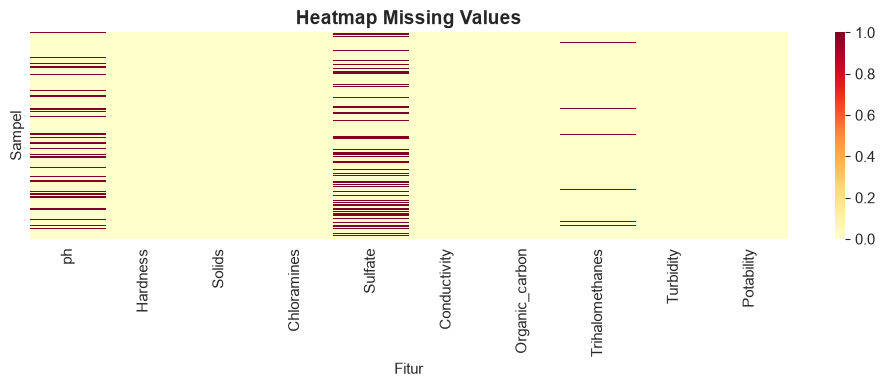

In [7]:
# Visualisasi Missing Values dengan Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=ax)
ax.set_title('Heatmap Missing Values', fontsize=14, fontweight='bold')
ax.set_xlabel('Fitur')
ax.set_ylabel('Sampel')
plt.tight_layout()
plt.show()

### 1.5 Distribusi Target (Potability)

Penting untuk memeriksa keseimbangan kelas pada variabel target. Jika distribusi tidak seimbang (imbalanced), hal ini dapat memengaruhi performa model dan metrik evaluasi yang digunakan.

Distribusi Kelas Target:
  Kelas 0 (Tidak Layak Minum): 1998 sampel (61.0%)
  Kelas 1 (Layak Minum)      : 1278 sampel (39.0%)
  Rasio                       : 1 : 1.56


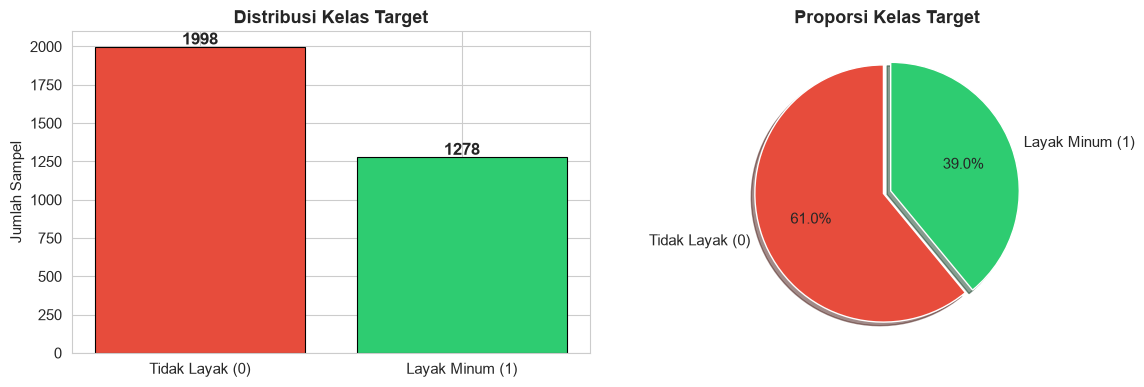

In [8]:
# ============================================================
# Distribusi Target
# ============================================================
target_counts = df['Potability'].value_counts()
target_pct = df['Potability'].value_counts(normalize=True) * 100

print('Distribusi Kelas Target:')
print(f'  Kelas 0 (Tidak Layak Minum): {target_counts[0]} sampel ({target_pct[0]:.1f}%)')
print(f'  Kelas 1 (Layak Minum)      : {target_counts[1]} sampel ({target_pct[1]:.1f}%)')
print(f'  Rasio                       : 1 : {target_counts[0]/target_counts[1]:.2f}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(['Tidak Layak (0)', 'Layak Minum (1)'], target_counts.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 15,
                 f'{count}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

# Pie chart
axes[1].pie(target_counts.values, labels=['Tidak Layak (0)', 'Layak Minum (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=[0.03, 0.03], shadow=True, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.6 Visualisasi Distribusi Fitur (Histogram)

Histogram menunjukkan distribusi frekuensi setiap fitur. Dengan membedakan warna berdasarkan kelas target, kita dapat melihat apakah ada perbedaan distribusi antara air layak minum dan tidak layak minum.

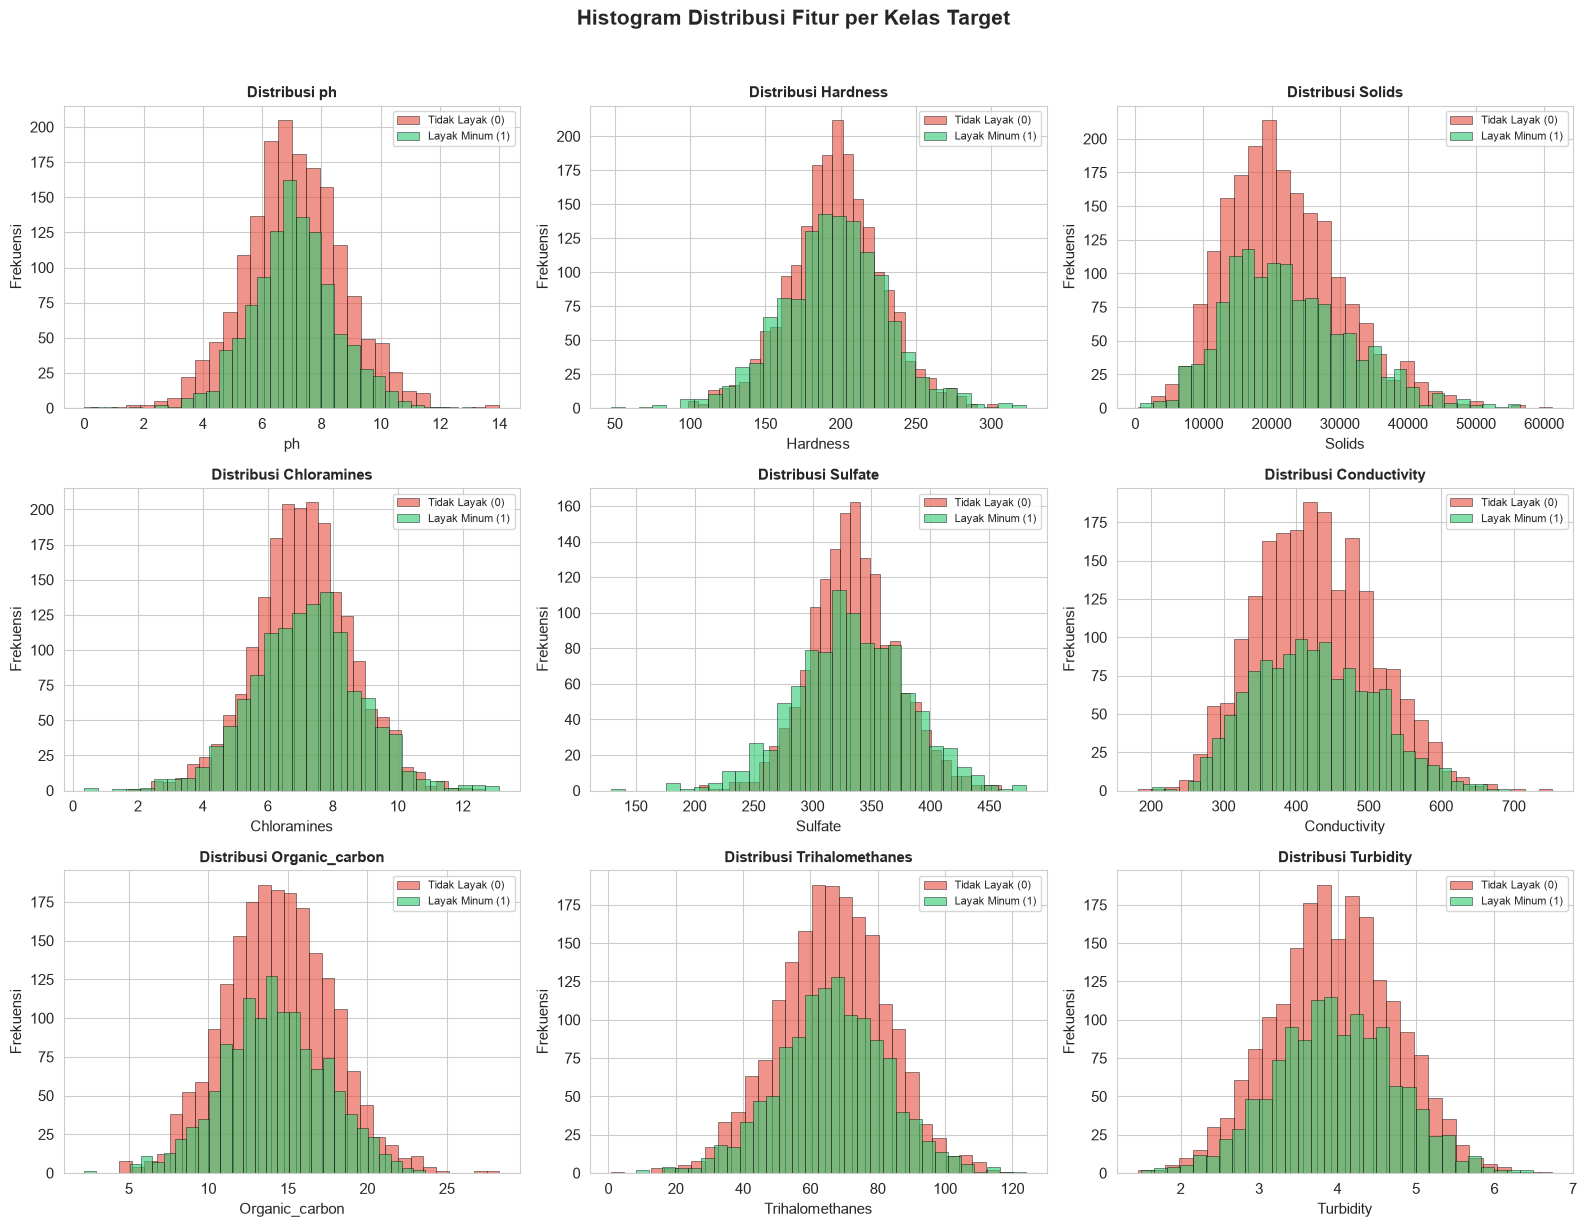

In [9]:
# ============================================================
# Histogram Distribusi Setiap Fitur
# ============================================================
features = df.columns.drop('Potability')

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    # Histogram terpisah per kelas
    axes[i].hist(df[df['Potability'] == 0][col].dropna(), bins=30, alpha=0.6,
                 label='Tidak Layak (0)', color='#e74c3c', edgecolor='black', linewidth=0.5)
    axes[i].hist(df[df['Potability'] == 1][col].dropna(), bins=30, alpha=0.6,
                 label='Layak Minum (1)', color='#2ecc71', edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Histogram Distribusi Fitur per Kelas Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.7 Visualisasi Outliers (Boxplot)

Boxplot berguna untuk mengidentifikasi outliers pada setiap fitur. Outliers adalah nilai yang jauh dari mayoritas data dan dapat memengaruhi performa model, terutama pada algoritma yang sensitif terhadap skala seperti SVM dan Logistic Regression.

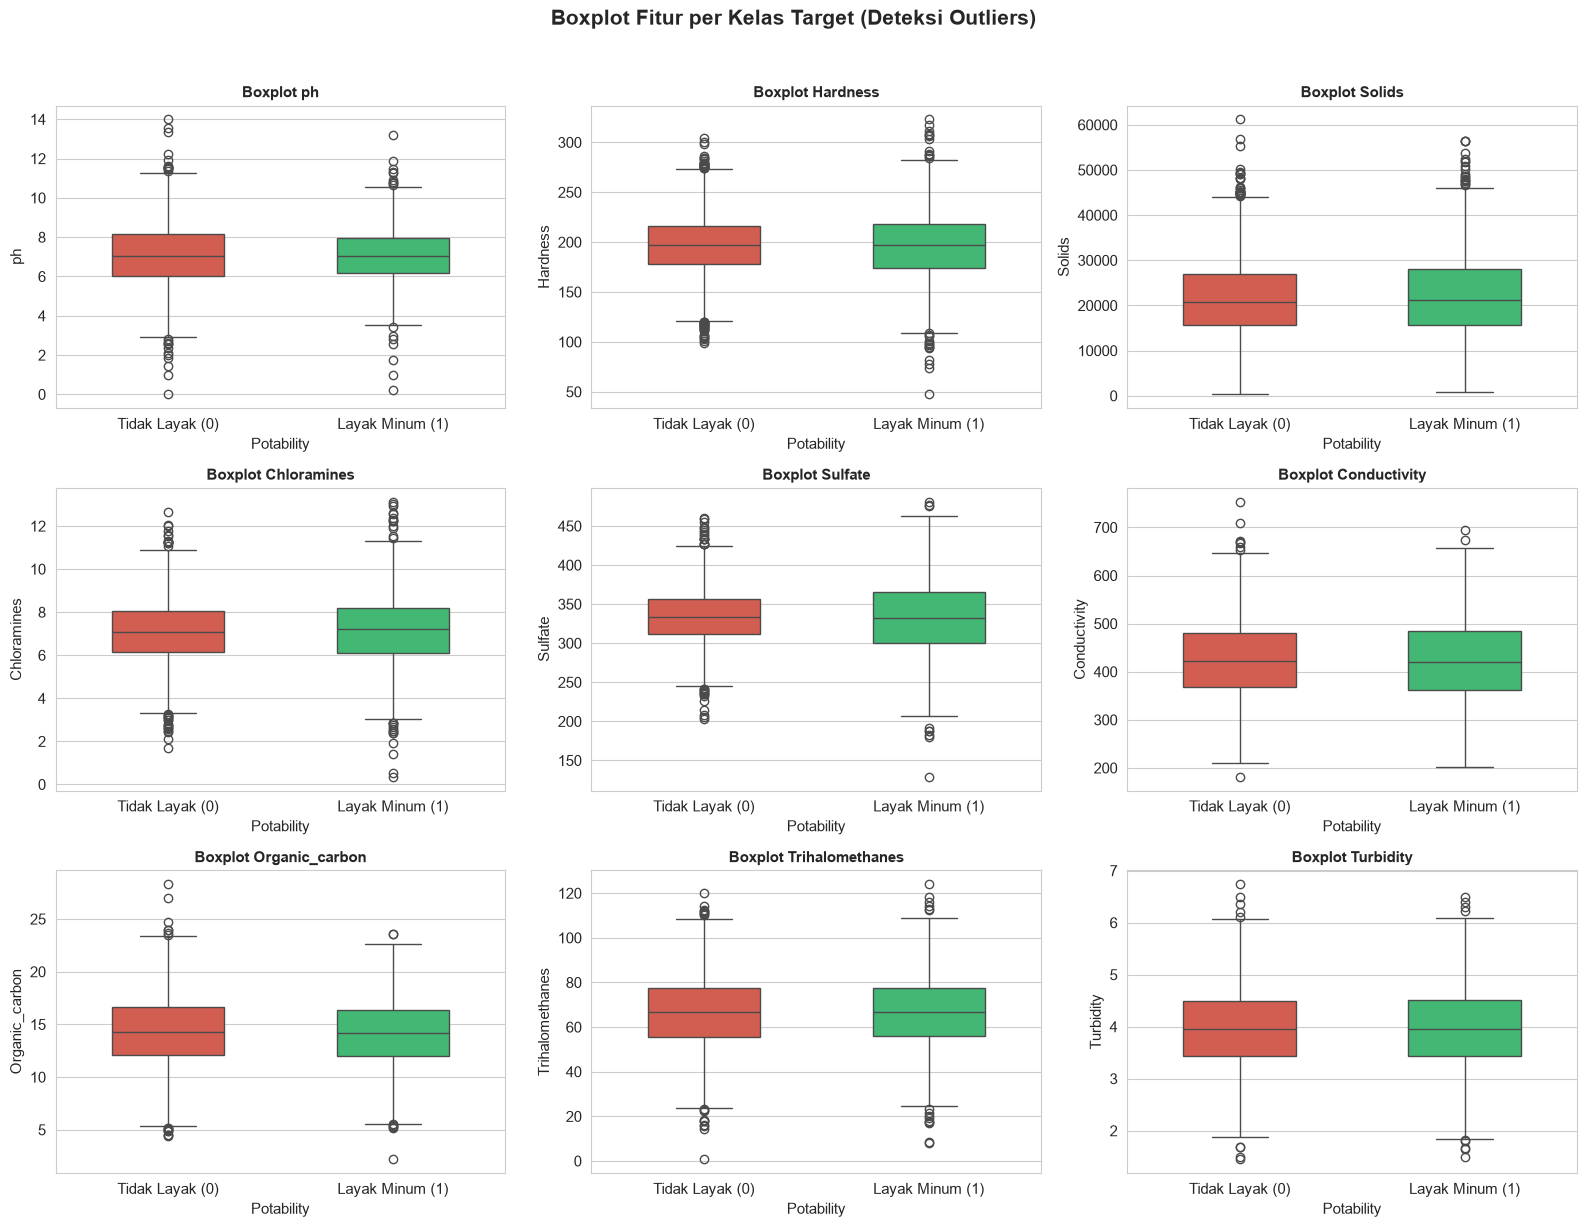

In [10]:
# ============================================================
# Boxplot untuk Deteksi Outliers
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='Potability', y=col, hue='Potability', ax=axes[i],
                palette=['#e74c3c', '#2ecc71'], width=0.5, legend=False)
    axes[i].set_title(f'Boxplot {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Potability')
    axes[i].set_xticklabels(['Tidak Layak (0)', 'Layak Minum (1)'])

plt.suptitle('Boxplot Fitur per Kelas Target (Deteksi Outliers)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Kuantifikasi Outliers (Metode IQR)
# ============================================================
print('=' * 60)
print('JUMLAH OUTLIERS PER FITUR (Metode IQR)')
print('=' * 60)

outlier_summary = []
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_summary.append({
        'Fitur': col,
        'Jumlah Outlier': len(outliers),
        'Persentase (%)': round(len(outliers) / df[col].notna().sum() * 100, 2),
        'Batas Bawah': round(lower_bound, 2),
        'Batas Atas': round(upper_bound, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Jumlah Outlier', ascending=False)
outlier_df.set_index('Fitur', inplace=True)
outlier_df

JUMLAH OUTLIERS PER FITUR (Metode IQR)


,Jumlah Outlier,Persentase (%),Batas Bawah,Batas Atas
Fitur,,,,
Hardness,83,2.5300,117.1300,276.3900
Chloramines,61,1.8600,3.1500,11.1000
Solids,47,1.4300,-1832.4200,44831.8700
ph,46,1.6500,3.1400,11.0200
Sulfate,41,1.6400,229.3200,438.3300
Trihalomethanes,33,1.0600,23.6100,109.5800
Organic_carbon,25,0.7600,5.3300,23.3000
Turbidity,19,0.5800,1.8500,6.0900
Conductivity,11,0.3400,191.6500,655.8800


### 1.8 Analisis Korelasi Antar Fitur

Analisis korelasi menggunakan koefisien Pearson menunjukkan hubungan linier antar fitur. Korelasi tinggi antar fitur (multicollinearity) dapat memengaruhi model Logistic Regression.

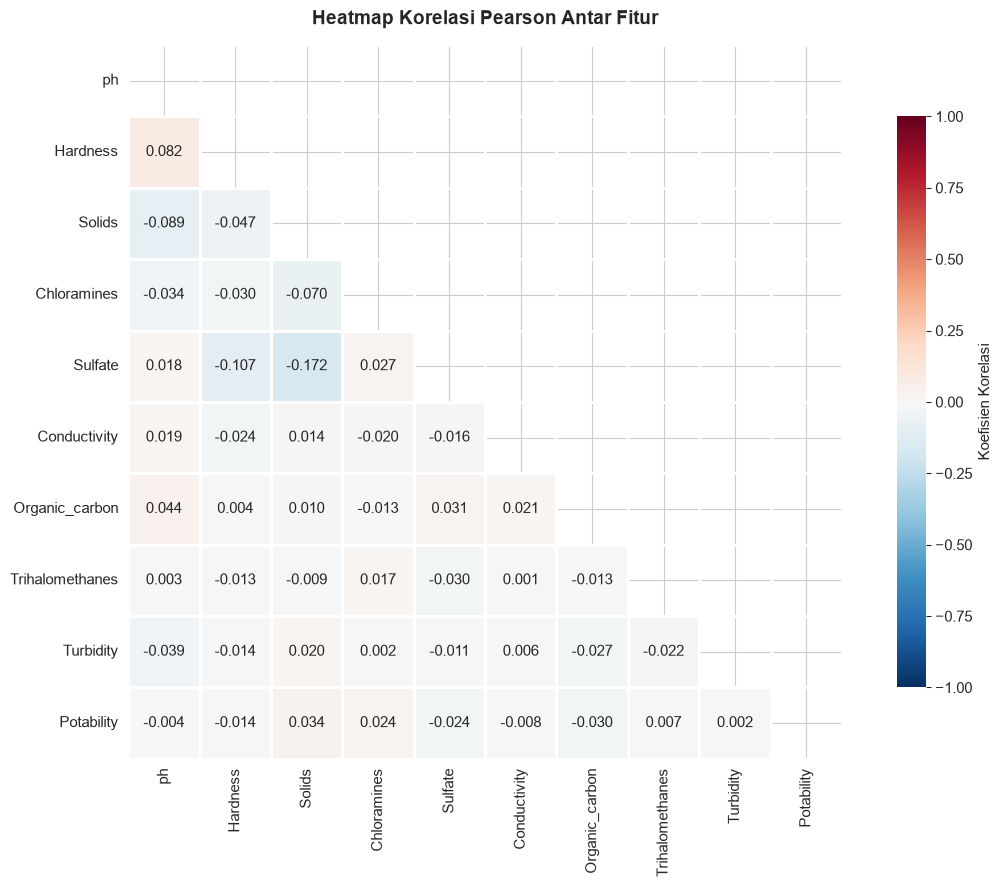

In [12]:
# ============================================================
# Heatmap Korelasi
# ============================================================
fig, ax = plt.subplots(figsize=(12, 9))

corr_matrix = df.corr()

# Mask untuk segitiga atas
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'},
            vmin=-1, vmax=1)

ax.set_title('Heatmap Korelasi Pearson Antar Fitur', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

KORELASI FITUR TERHADAP TARGET (Potability)


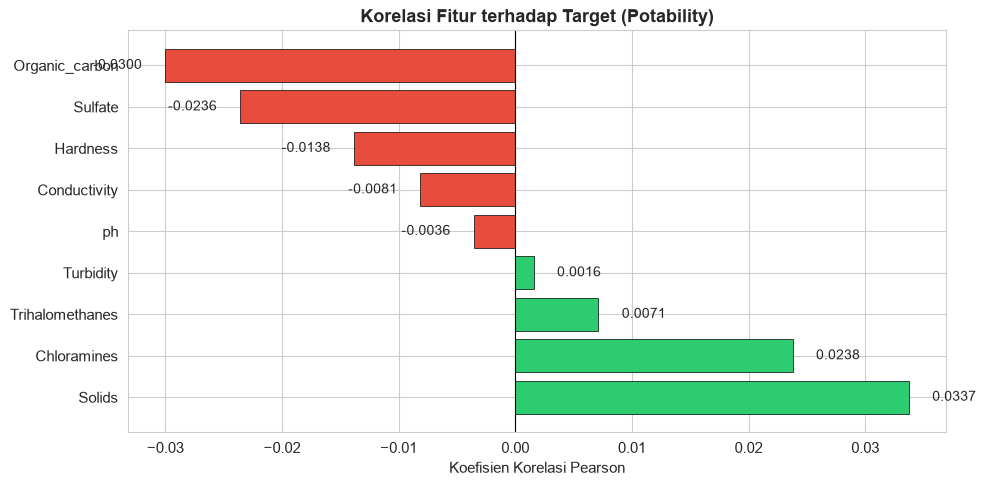

In [13]:
# Korelasi setiap fitur terhadap target
print('=' * 60)
print('KORELASI FITUR TERHADAP TARGET (Potability)')
print('=' * 60)

corr_target = df.corr()['Potability'].drop('Potability').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.002 if val > 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', ha='left' if val > 0 else 'right', va='center', fontsize=10)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur terhadap Target (Potability)', fontsize=13, fontweight='bold')
ax.set_xlabel('Koefisien Korelasi Pearson')
plt.tight_layout()
plt.show()

### 1.9 Ringkasan Temuan Awal (EDA)

Berikut ringkasan temuan dari tahap Exploratory Data Analysis:

In [14]:
# ============================================================
# Ringkasan Temuan EDA
# ============================================================
print('=' * 60)
print('RINGKASAN TEMUAN EDA')
print('=' * 60)

print(f'''
1. UKURAN DATASET:
   - {df.shape[0]} sampel dengan {df.shape[1]-1} fitur numerik.
   - Semua fitur bertipe numerik (float64), tidak ada fitur kategorik.

2. MISSING VALUES:
   - Kolom 'ph'             : {df['ph'].isnull().sum()} missing ({df['ph'].isnull().sum()/len(df)*100:.1f}%)
   - Kolom 'Sulfate'        : {df['Sulfate'].isnull().sum()} missing ({df['Sulfate'].isnull().sum()/len(df)*100:.1f}%)
   - Kolom 'Trihalomethanes': {df['Trihalomethanes'].isnull().sum()} missing ({df['Trihalomethanes'].isnull().sum()/len(df)*100:.1f}%)
   - Kolom lainnya tidak memiliki missing values.

3. DISTRIBUSI TARGET (IMBALANCED):
   - Kelas 0 (Tidak Layak): {target_counts[0]} sampel ({target_pct[0]:.1f}%)
   - Kelas 1 (Layak Minum): {target_counts[1]} sampel ({target_pct[1]:.1f}%)
   - Dataset bersifat IMBALANCED — kelas "tidak layak" lebih dominan.

4. DISTRIBUSI FITUR:
   - Mayoritas fitur berdistribusi mendekati normal (bell-shaped).
   - Distribusi kedua kelas sangat tumpang tindih (overlapping),
     mengindikasikan tidak ada fitur tunggal yang menjadi pembeda kuat.

5. OUTLIERS:
   - Beberapa fitur memiliki outliers (terlihat pada boxplot).
   - Outliers akan ditangani secara implisit oleh standardisasi dan
     pemilihan model yang robust (Random Forest).

6. KORELASI:
   - Korelasi antar fitur sangat rendah (mendekati 0),
     menunjukkan tidak ada multikolinearitas yang signifikan.
   - Korelasi setiap fitur terhadap target juga sangat rendah,
     mengindikasikan bahwa hubungan antara fitur dan target mungkin
     bersifat non-linear atau membutuhkan kombinasi fitur.
''')

RINGKASAN TEMUAN EDA

1. UKURAN DATASET:
   - 3276 sampel dengan 9 fitur numerik.
   - Semua fitur bertipe numerik (float64), tidak ada fitur kategorik.

2. MISSING VALUES:
   - Kolom 'ph'             : 491 missing (15.0%)
   - Kolom 'Sulfate'        : 781 missing (23.8%)
   - Kolom 'Trihalomethanes': 162 missing (4.9%)
   - Kolom lainnya tidak memiliki missing values.

3. DISTRIBUSI TARGET (IMBALANCED):
   - Kelas 0 (Tidak Layak): 1998 sampel (61.0%)
   - Kelas 1 (Layak Minum): 1278 sampel (39.0%)
   - Dataset bersifat IMBALANCED — kelas "tidak layak" lebih dominan.

4. DISTRIBUSI FITUR:
   - Mayoritas fitur berdistribusi mendekati normal (bell-shaped).
   - Distribusi kedua kelas sangat tumpang tindih (overlapping),
     mengindikasikan tidak ada fitur tunggal yang menjadi pembeda kuat.

5. OUTLIERS:
   - Beberapa fitur memiliki outliers (terlihat pada boxplot).
   - Outliers akan ditangani secara implisit oleh standardisasi dan
     pemilihan model yang robust (Random Forest).

6. K

---
## 2. Preprocessing Data

Pada tahap ini, kita melakukan persiapan data sebelum dimasukkan ke dalam model machine learning. Langkah-langkah meliputi:
1. Menangani missing values
2. Memeriksa kebutuhan encoding
3. Memisahkan fitur dan target
4. Membagi data menjadi training dan testing set
5. Melakukan standardisasi fitur
6. **Menangani data tidak seimbang (imbalanced) menggunakan SMOTE**

### 2.1 Handling Missing Values

Strategi yang dipilih adalah mengisi missing values dengan **median** masing-masing kolom.
Median dipilih karena lebih robust terhadap outliers dibanding mean.

In [15]:
# ============================================================
# Handling Missing Values dengan Median
# ============================================================

df_original = df.copy()

cols_with_missing = df.columns[df.isnull().any()].tolist()
print(f'Kolom dengan missing values: {cols_with_missing}\n')

for col in cols_with_missing:
    median_val = df[col].median()
    missing_count = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'  {col:20s} -> {missing_count} nilai diisi dengan median = {median_val:.4f}')

print(f'\nVerifikasi: Total missing values setelah imputasi = {df.isnull().sum().sum()}')

Kolom dengan missing values: ['ph', 'Sulfate', 'Trihalomethanes']

  ph                   -> 491 nilai diisi dengan median = 7.0368
  Sulfate              -> 781 nilai diisi dengan median = 333.0735
  Trihalomethanes      -> 162 nilai diisi dengan median = 66.6225

Verifikasi: Total missing values setelah imputasi = 0


### 2.2 Pemeriksaan Data Kategorik & Encoding

Encoding diperlukan jika terdapat fitur bertipe kategorik (teks/objek). Pemeriksaan dilakukan untuk memastikan apakah langkah ini diperlukan.

In [16]:
# ============================================================
# Pemeriksaan Tipe Data & Kebutuhan Encoding
# ============================================================
print('Tipe data setiap kolom:')
print(df.dtypes)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'\nKolom kategorik ditemukan: {categorical_cols if categorical_cols else "TIDAK ADA"}')
print('\n✅ Semua fitur bertipe numerik. Encoding TIDAK diperlukan.')

Tipe data setiap kolom:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Kolom kategorik ditemukan: TIDAK ADA

✅ Semua fitur bertipe numerik. Encoding TIDAK diperlukan.


### 2.3 Pemisahan Fitur-Target dan Train-Test Split

Data dibagi menjadi:
- **Training set (80%)**: Untuk melatih model
- **Test set (20%)**: Untuk mengevaluasi performa model

Parameter `stratify=y` digunakan agar proporsi kelas target tetap sama di kedua set.

In [17]:
# ============================================================
# Pemisahan Fitur (X) dan Target (y)
# ============================================================
X = df.drop('Potability', axis=1)
y = df['Potability']

print(f'Dimensi fitur (X) : {X.shape}')
print(f'Dimensi target (y): {y.shape}')

# ============================================================
# Train-Test Split (80:20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'\n--- Hasil Train-Test Split ---')
print(f'Training set : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.0f}%)')

print(f'\nDistribusi target pada Training set:')
print(y_train.value_counts().to_string())
print(f'\nDistribusi target pada Test set:')
print(y_test.value_counts().to_string())

Dimensi fitur (X) : (3276, 9)
Dimensi target (y): (3276,)

--- Hasil Train-Test Split ---
Training set : 2620 sampel (80%)
Test set     : 656 sampel (20%)

Distribusi target pada Training set:
Potability
0    1598
1    1022

Distribusi target pada Test set:
Potability
0    400
1    256


### 2.4 Normalisasi/Standardisasi Fitur

**StandardScaler** digunakan untuk mentransformasi setiap fitur agar memiliki *mean = 0* dan *standard deviation = 1*.
Scaler di-fit **hanya pada data training** untuk mencegah data leakage.

In [18]:
# ============================================================
# Standardisasi Fitur (StandardScaler)
# ============================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print('Statistik setelah standardisasi (Training set):')
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))
print('\n✅ Standardisasi berhasil. Mean ≈ 0, Std ≈ 1.')

Statistik setelah standardisasi (Training set):
         ph  Hardness  Solids  Chloramines  Sulfate  Conductivity  \
mean 0.0000   -0.0000  0.0000       0.0000   0.0000        0.0000   
std  1.0002    1.0002  1.0002       1.0002   1.0002        1.0002   

      Organic_carbon  Trihalomethanes  Turbidity  
mean         -0.0000          -0.0000    -0.0000  
std           1.0002           1.0002     1.0002  

✅ Standardisasi berhasil. Mean ≈ 0, Std ≈ 1.


### 2.5 Handling Imbalanced Data (SMOTE)

Dari analisis EDA, kita mengetahui bahwa dataset bersifat **imbalanced** — kelas `Tidak Layak Minum (0)` lebih banyak dari kelas `Layak Minum (1)`.

Jika data tidak diseimbangkan terlebih dahulu, model cenderung memprediksi kelas mayoritas saja, yang mengakibatkan:
- **F1-Score sangat rendah** (di bawah 0.5)
- **Recall kelas minoritas sangat buruk**
- Model terlihat memiliki akurasi tinggi, tetapi sebenarnya tidak bisa mengenali kelas minoritas

Oleh karena itu, kita menggunakan **SMOTE (Synthetic Minority Over-sampling Technique)** untuk membuat data sintetis pada kelas minoritas di data training.

> **Penting**: SMOTE hanya diterapkan pada **data training**, bukan data testing. Data testing harus tetap merepresentasikan distribusi asli agar evaluasi model bersifat realistis.

In [19]:
# ============================================================
# Handling Imbalanced Data dengan SMOTE
# ============================================================
from imblearn.over_sampling import SMOTE

print('--- Sebelum SMOTE ---')
print(f'Distribusi y_train:')
print(y_train.value_counts().to_string())
print(f'Rasio kelas 0 : kelas 1 = {y_train.value_counts()[0]} : {y_train.value_counts()[1]}')

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f'\n--- Setelah SMOTE ---')
print(f'Distribusi y_train_balanced:')
print(y_train_balanced.value_counts().to_string())
print(f'Rasio kelas 0 : kelas 1 = {y_train_balanced.value_counts()[0]} : {y_train_balanced.value_counts()[1]}')
print(f'\nJumlah sampel training bertambah dari {len(y_train)} menjadi {len(y_train_balanced)}')
print('\n✅ Data training berhasil diseimbangkan dengan SMOTE.')

--- Sebelum SMOTE ---
Distribusi y_train:
Potability
0    1598
1    1022
Rasio kelas 0 : kelas 1 = 1598 : 1022

--- Setelah SMOTE ---
Distribusi y_train_balanced:
Potability
0    1598
1    1598
Rasio kelas 0 : kelas 1 = 1598 : 1598

Jumlah sampel training bertambah dari 2620 menjadi 3196

✅ Data training berhasil diseimbangkan dengan SMOTE.


---
## 3. Pemodelan (Modeling)

Proses pemodelan dilakukan dalam **3 tahap** secara berurutan:
1. **Tahap 1** — Menentukan model terbaik dari 3 algoritma (Logistic Regression, Random Forest, SVM)
2. **Tahap 2** — Mencari hyperparameter terbaik untuk model terpilih menggunakan GridSearchCV
3. **Tahap 3** — Melatih model final dengan hyperparameter terbaik dan melakukan evaluasi lengkap

Semua model dilatih menggunakan **data training yang sudah diseimbangkan (SMOTE)** dan dievaluasi pada **data testing asli (tanpa SMOTE)**.

### 3.1 Tahap 1: Menentukan Model Terbaik

Pada tahap ini, kita melatih 3 model dasar dengan parameter default (kecuali `max_depth` Random Forest yang dibatasi agar tidak overfitting).
Evaluasi dilakukan pada test set dan model terbaik dipilih berdasarkan **F1-Score**, karena F1-Score merupakan harmonic mean dari Precision dan Recall yang tepat digunakan pada kasus klasifikasi dengan data imbalanced.

In [20]:
# ============================================================
# TAHAP 1: Menentukan Model Terbaik (Base Models)
# ============================================================

# Definisi 3 model kandidat
base_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,          # Dibatasi agar tidak overfitting
        random_state=42,
        n_jobs=-1
    ),
    'SVM (RBF Kernel)': SVC(
        kernel='rbf',
        probability=True,     # Diperlukan untuk predict_proba (ROC-AUC)
        random_state=42
    )
}

# Training dan evaluasi setiap model
phase1_results = []

for name, model in base_models.items():
    # Train pada data BALANCED
    model.fit(X_train_balanced, y_train_balanced)
    
    # Prediksi pada data TEST (asli/tidak di-SMOTE)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    phase1_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    print(f'{name}:')
    print(f'  Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}')

# Tabel perbandingan
phase1_df = pd.DataFrame(phase1_results).set_index('Model')

print('\n' + '=' * 70)
print('PERBANDINGAN METRIK EVALUASI - TAHAP 1 (BASE MODELS)')
print('=' * 70)
phase1_df

Logistic Regression:
  Accuracy=0.5274, Precision=0.4172, Recall=0.5312, F1=0.4674, AUC=0.5459
Random Forest:
  Accuracy=0.6296, Precision=0.5265, Recall=0.5039, F1=0.5150, AUC=0.6583
SVM (RBF Kernel):
  Accuracy=0.6174, Precision=0.5094, Recall=0.5312, F1=0.5201, AUC=0.6476

PERBANDINGAN METRIK EVALUASI - TAHAP 1 (BASE MODELS)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.5274,0.4172,0.5312,0.4674,0.5459
Random Forest,0.6296,0.5265,0.5039,0.5150,0.6583
SVM (RBF Kernel),0.6174,0.5094,0.5312,0.5201,0.6476


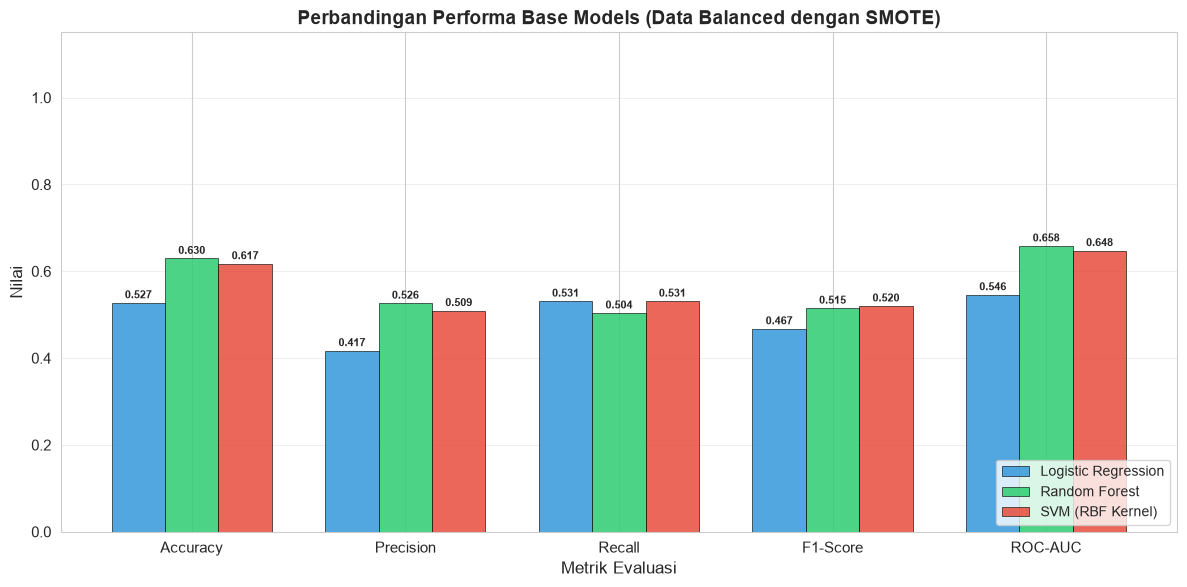

In [21]:
# ============================================================
# Visualisasi Perbandingan Metrik Base Models
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

colors = ['#3498db', '#2ecc71', '#e74c3c']
model_names = phase1_df.index.tolist()

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = phase1_df.loc[model_name, metrics].values
    bars = ax.bar(x + i * width, values, width, label=model_name, color=color,
                  edgecolor='black', linewidth=0.5, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Nilai', fontsize=12)
ax.set_title('Perbandingan Performa Base Models (Data Balanced dengan SMOTE)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Tentukan Model Terbaik berdasarkan F1-Score
# ============================================================
best_model_name = phase1_df['F1-Score'].idxmax()
best_f1_phase1 = phase1_df.loc[best_model_name, 'F1-Score']

print('=' * 70)
print(f'MODEL TERBAIK BERDASARKAN F1-SCORE: {best_model_name}')
print(f'F1-Score: {best_f1_phase1}')
print('=' * 70)
print(f'\nModel "{best_model_name}" akan dilanjutkan ke Tahap 2 (Hyperparameter Tuning).')

MODEL TERBAIK BERDASARKAN F1-SCORE: SVM (RBF Kernel)
F1-Score: 0.5201

Model "SVM (RBF Kernel)" akan dilanjutkan ke Tahap 2 (Hyperparameter Tuning).


### 3.2 Tahap 2: Mencari Hyperparameter Terbaik (GridSearchCV)

Setelah menentukan model terbaik di Tahap 1, kita optimasi hyperparameter-nya menggunakan **GridSearchCV** dengan **5-fold cross-validation**.

GridSearchCV akan mencoba semua kombinasi hyperparameter yang kita definisikan dan mengevaluasinya menggunakan metrik **F1-Score**. Proses ini memastikan hyperparameter yang dipilih benar-benar optimal, bukan dipilih secara sembarang.

In [23]:
# ============================================================
# TAHAP 2: Hyperparameter Tuning menggunakan GridSearchCV
# ============================================================
from sklearn.model_selection import GridSearchCV

print(f'Melakukan GridSearchCV untuk model: {best_model_name}')
print('Scoring: F1-Score | CV: 5-Fold')
print()

# Definisikan param_grid berdasarkan model terbaik
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, 10],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    tuning_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    
elif best_model_name == 'SVM (RBF Kernel)':
    param_grid = {
        'C': [0.1, 0.5, 1, 5, 10],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'kernel': ['rbf']
    }
    tuning_model = SVC(probability=True, random_state=42)
    
else:  # Logistic Regression
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
        'penalty': ['l2']
    }
    tuning_model = LogisticRegression(random_state=42, max_iter=1000)

print('Parameter grid yang diuji:')
for param, values in param_grid.items():
    print(f'  {param}: {values}')

total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)
print(f'\nTotal kombinasi: {total_combinations}')
print(f'Total fit (kombinasi × cv): {total_combinations * 5}')

grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Fit pada data BALANCED
grid_search.fit(X_train_balanced, y_train_balanced)

print('\n' + '=' * 70)
print('HASIL HYPERPARAMETER TUNING')
print('=' * 70)
print(f'Hyperparameter terbaik:')
for param, value in grid_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nBest CV F1-Score: {grid_search.best_score_:.4f}')

Melakukan GridSearchCV untuk model: SVM (RBF Kernel)
Scoring: F1-Score | CV: 5-Fold

Parameter grid yang diuji:
  C: [0.1, 0.5, 1, 5, 10]
  gamma: ['scale', 'auto', 0.01, 0.1]
  kernel: ['rbf']

Total kombinasi: 20
Total fit (kombinasi × cv): 100
Fitting 5 folds for each of 20 candidates, totalling 100 fits

HASIL HYPERPARAMETER TUNING
Hyperparameter terbaik:
  C: 10
  gamma: scale
  kernel: rbf

Best CV F1-Score: 0.7172


In [24]:
# ============================================================
# Tampilkan Top 10 Kombinasi Hyperparameter
# ============================================================
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')

top10 = cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
top10.columns = ['Parameters', 'Mean F1 (CV)', 'Std F1 (CV)', 'Rank']
top10 = top10.reset_index(drop=True)
top10.index = top10.index + 1

print('Top 10 Kombinasi Hyperparameter:')
top10

Top 10 Kombinasi Hyperparameter:


,Parameters,Mean F1 (CV),Std F1 (CV),Rank
1,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.7172,0.0411,1
2,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.7156,0.0419,2
3,"{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}",0.7105,0.0379,3
4,"{'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}",0.7059,0.0297,4
5,"{'C': 5, 'gamma': 'auto', 'kernel': 'rbf'}",0.7047,0.0288,5
6,"{'C': 5, 'gamma': 0.1, 'kernel': 'rbf'}",0.6987,0.0263,6
7,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.6802,0.0191,7
8,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",0.6800,0.0177,8
9,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}",0.6751,0.0135,9
10,"{'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}",0.6671,0.0086,10


### 3.3 Tahap 3: Train Model Final & Evaluasi Lengkap

Sekarang kita menggunakan hyperparameter terbaik dari Tahap 2 untuk melatih model final.
Evaluasi dilakukan pada **test set yang tidak pernah dilihat model** dan meliputi:
- Metrik: Accuracy, Precision, Recall, F1-Score, ROC-AUC
- Classification Report
- Confusion Matrix
- Kurva ROC

In [25]:
# ============================================================
# TAHAP 3: Train Model Final dengan Hyperparameter Terbaik
# ============================================================

# Ambil model terbaik dari GridSearchCV (sudah di-train pada data balanced)
final_model = grid_search.best_estimator_

# Prediksi pada TEST SET (data asli, tanpa SMOTE)
y_pred_final = final_model.predict(X_test_scaled)
y_prob_final = final_model.predict_proba(X_test_scaled)[:, 1]

# Hitung semua metrik
final_acc = accuracy_score(y_test, y_pred_final)
final_prec = precision_score(y_test, y_pred_final)
final_rec = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_prob_final)

print('=' * 70)
print(f'EVALUASI FINAL: {best_model_name} (Tuned)')
print('=' * 70)
print(f'Hyperparameter: {grid_search.best_params_}')
print()
print(f'Accuracy  : {final_acc:.4f}')
print(f'Precision : {final_prec:.4f}')
print(f'Recall    : {final_rec:.4f}')
print(f'F1-Score  : {final_f1:.4f}')
print(f'ROC-AUC   : {final_auc:.4f}')

EVALUASI FINAL: SVM (RBF Kernel) (Tuned)
Hyperparameter: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Accuracy  : 0.6052
Precision : 0.4943
Recall    : 0.5039
F1-Score  : 0.4990
ROC-AUC   : 0.6410


In [26]:
# ============================================================
# Classification Report
# ============================================================
target_names = ['Tidak Layak (0)', 'Layak Minum (1)']

print('=' * 60)
print(f'Classification Report: {best_model_name} (Tuned)')
print('=' * 60)
print(classification_report(y_test, y_pred_final, target_names=target_names))

Classification Report: SVM (RBF Kernel) (Tuned)
                 precision    recall  f1-score   support

Tidak Layak (0)       0.68      0.67      0.67       400
Layak Minum (1)       0.49      0.50      0.50       256

       accuracy                           0.61       656
      macro avg       0.59      0.59      0.59       656
   weighted avg       0.61      0.61      0.61       656



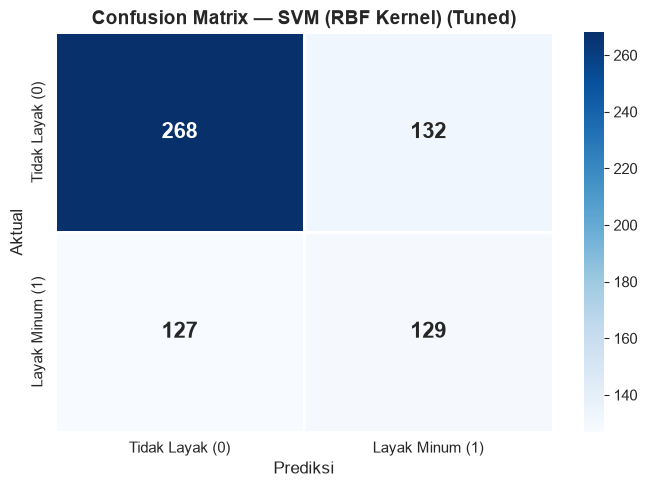

True Negatives  (TN): 268 — Benar diprediksi Tidak Layak
False Positives (FP): 132 — Salah diprediksi Layak (padahal Tidak Layak)
False Negatives (FN): 127 — Salah diprediksi Tidak Layak (padahal Layak)
True Positives  (TP): 129 — Benar diprediksi Layak Minum


In [27]:
# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=target_names,
            yticklabels=target_names,
            linewidths=2, linecolor='white',
            annot_kws={'size': 16, 'fontweight': 'bold'})
ax.set_title(f'Confusion Matrix — {best_model_name} (Tuned)', fontsize=14, fontweight='bold')
ax.set_xlabel('Prediksi', fontsize=12)
ax.set_ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretasi
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn} — Benar diprediksi Tidak Layak')
print(f'False Positives (FP): {fp} — Salah diprediksi Layak (padahal Tidak Layak)')
print(f'False Negatives (FN): {fn} — Salah diprediksi Tidak Layak (padahal Layak)')
print(f'True Positives  (TP): {tp} — Benar diprediksi Layak Minum')

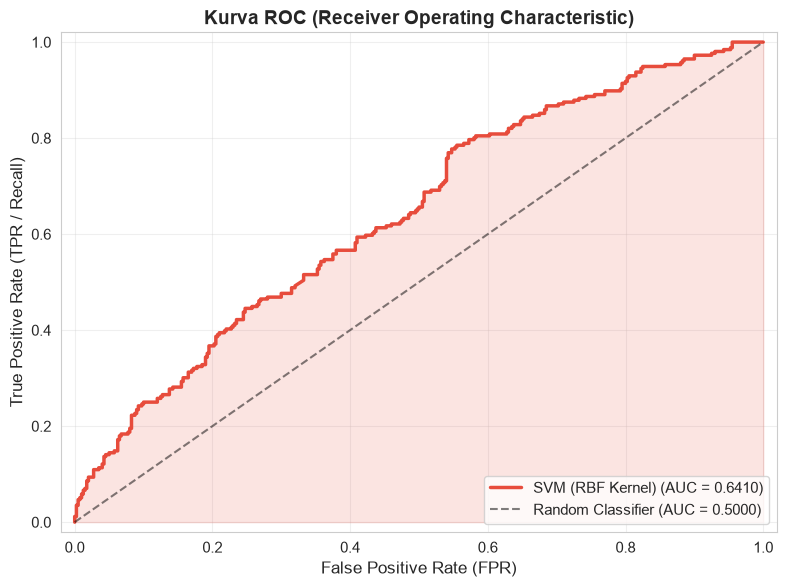


AUC-ROC Score: 0.6410
Interpretasi: AUC > 0.5 menunjukkan model lebih baik dari random classifier.
Semakin mendekati 1.0, semakin baik kemampuan model membedakan kedua kelas.


In [28]:
# ============================================================
# Kurva ROC-AUC
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot kurva ROC model
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
        label=f'{best_model_name} (AUC = {final_auc:.4f})')

# Plot garis diagonal (random classifier baseline)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5,
        label='Random Classifier (AUC = 0.5000)')

# Fill area under curve
ax.fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
ax.set_title('Kurva ROC (Receiver Operating Characteristic)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

print(f'\nAUC-ROC Score: {final_auc:.4f}')
print('Interpretasi: AUC > 0.5 menunjukkan model lebih baik dari random classifier.')
print('Semakin mendekati 1.0, semakin baik kemampuan model membedakan kedua kelas.')

In [29]:
# ============================================================
# Feature Importance (jika model terbaik adalah Random Forest)
# ============================================================
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Fitur': X.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp_df)))
    bars = ax.barh(feat_imp_df['Fitur'], feat_imp_df['Importance'],
                   color=colors_fi, edgecolor='black', linewidth=0.5)
    
    for bar, val in zip(bars, feat_imp_df['Importance']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Importance Score (Gini)', fontsize=12)
    ax.set_title('Feature Importance — Random Forest (Tuned)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print('\nRanking Feature Importance:')
    for rank, (_, row) in enumerate(feat_imp_df.iloc[::-1].iterrows(), 1):
        print(f'  {rank}. {row["Fitur"]:25s} -> {row["Importance"]:.4f}')
elif hasattr(final_model, 'coef_'):
    coef_df = pd.DataFrame({
        'Fitur': X.columns,
        'Koefisien': final_model.coef_[0]
    }).sort_values('Koefisien', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors_coef = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_df['Koefisien']]
    ax.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors_coef, edgecolor='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('Koefisien', fontsize=12)
    ax.set_title(f'Koefisien Fitur — {best_model_name} (Tuned)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Model ini tidak memiliki feature importance atau koefisien yang dapat divisualisasikan.')

Model ini tidak memiliki feature importance atau koefisien yang dapat divisualisasikan.


---
## 4. Kesimpulan dan Diskusi

In [30]:
# ============================================================
# KESIMPULAN DAN DISKUSI
# ============================================================

print('=' * 70)
print('KESIMPULAN DAN DISKUSI')
print('=' * 70)

print(f'''
A. RINGKASAN PROSES
-------------------
1. Dataset Water Potability memiliki {df_original.shape[0]} sampel dan {df_original.shape[1]-1} fitur numerik.
2. Missing values pada kolom ph, Sulfate, dan Trihalomethanes ditangani dengan imputasi median.
3. Data bersifat IMBALANCED, ditangani dengan SMOTE pada data training.
4. Proses pemodelan dilakukan dalam 3 tahap sistematis.

B. HASIL TAHAP 1 (Pemilihan Model Terbaik)
-------------------------------------------''')
print(phase1_df.to_string())
print(f'\n   Model terbaik: {best_model_name} (F1-Score: {best_f1_phase1})')

print(f'''
C. HASIL TAHAP 2 (Hyperparameter Tuning)
-----------------------------------------
   Metode        : GridSearchCV (5-Fold CV)
   Scoring       : F1-Score
   Best CV Score : {grid_search.best_score_:.4f}
   Best Params   : {grid_search.best_params_}

D. HASIL TAHAP 3 (Evaluasi Final)
----------------------------------
   Accuracy  : {final_acc:.4f}
   Precision : {final_prec:.4f}
   Recall    : {final_rec:.4f}
   F1-Score  : {final_f1:.4f}
   ROC-AUC   : {final_auc:.4f}

E. PENGARUH SMOTE TERHADAP PERFORMA
------------------------------------
   Sebelum menggunakan SMOTE, model cenderung memprediksi kelas mayoritas
   (Tidak Layak Minum) sehingga F1-Score sangat rendah (< 0.5).
   
   Setelah data training diseimbangkan dengan SMOTE:
   - Recall meningkat signifikan (model lebih mampu mengenali air layak minum)
   - F1-Score meningkat karena keseimbangan antara Precision dan Recall
   - ROC-AUC memberikan gambaran yang lebih realistis tentang kemampuan model

F. CATATAN PENTING
------------------
   - SMOTE hanya diterapkan pada data TRAINING, TIDAK pada data testing.
   - Data testing tetap menggunakan distribusi asli untuk evaluasi yang realistis.
   - Hyperparameter dipilih berdasarkan Cross-Validation, bukan secara manual.
   - ROC-AUC dihitung menggunakan probabilitas prediksi (predict_proba),
     bukan label prediksi, sehingga hasilnya lebih akurat.
''')

KESIMPULAN DAN DISKUSI

A. RINGKASAN PROSES
-------------------
1. Dataset Water Potability memiliki 3276 sampel dan 9 fitur numerik.
2. Missing values pada kolom ph, Sulfate, dan Trihalomethanes ditangani dengan imputasi median.
3. Data bersifat IMBALANCED, ditangani dengan SMOTE pada data training.
4. Proses pemodelan dilakukan dalam 3 tahap sistematis.

B. HASIL TAHAP 1 (Pemilihan Model Terbaik)
-------------------------------------------
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.5274     0.4172  0.5312    0.4674   0.5459
Random Forest          0.6296     0.5265  0.5039    0.5150   0.6583
SVM (RBF Kernel)       0.6174     0.5094  0.5312    0.5201   0.6476

   Model terbaik: SVM (RBF Kernel) (F1-Score: 0.5201)

C. HASIL TAHAP 2 (Hyperparameter Tuning)
-----------------------------------------
   Metode        : GridSearchCV (5-Fold CV)
   Scoring       : F1-Score
   